# Chapter E. Spatio-temporal Processes

## Learning Objectives

After completing this chapter, you should be able to:
1. Construct lagged environmental predicates on a common eligible anchor-period population.
2. Simulate binary Markov environmental fields and interpret persistence（持续性）.
3. Distinguish lag-specific marginal association from identification of a causal delay.
4. Demonstrate seasonal target variation and why naive row permutations can fail.
5. Compute an empirical lag-profile for a known planted lag-2 mechanism.

**Connection to STARM:** The examples mirror the binary outcome, fixed antecedent indicators, lagged transactions, and overlapping spatial supports in the STARM manuscript. They are teaching examples, not reproductions of manuscript results.

> **Teaching philosophy:** start with the general statistical problem, build mathematical intuition, and use STARM as one illustrative case study. The new sections precede the original computational labs.

## Why Study This? — Motivation, Scope, and Real-World Problems

Many phenomena are dynamic: past conditions predict or accompany later events, seasons repeat, shocks propagate, and neighboring regions interact. **Spatio-temporal statistics (时空统计学)** extends spatial and time-series reasoning to observations indexed by both location and time. It is used for infectious-disease spread, air pollution, flood risk, urban mobility, and climate extremes.

**Questions it answers:** What persists through time? How do we distinguish a true delayed influence from autocorrelation? What is the difference between trend, seasonality and lagged association? How should we compare time offsets fairly?

---

## Conceptual Roadmap

**Scientific problem → statistical representation → assumptions → mathematics → computational experiment → diagnostics → interpretation.**

The chapters are standalone: STARM is a later application, not the reason these mathematical ideas exist.

## Foundations and Mathematical Derivations

### Temporal dependence is more than a lag
For a weakly stationary process $X_t$, $\gamma(h)=\mathrm{Cov}(X_t,X_{t-h})$ and $\rho(h)=\gamma(h)/\gamma(0)$ define autocovariance and autocorrelation. Stationarity (平稳性) means stable moments under time shifts, not identical observations.

An **AR(1)** model is $X_t=\phi X_{t-1}+\epsilon_t$ with mean-zero innovations and $|\phi|<1$. With independent innovations $\epsilon_t\sim(0,\sigma_\epsilon^2)$,

$$\gamma(0)=\frac{\sigma_\epsilon^2}{1-\phi^2},\qquad\rho(h)=\phi^{|h|}.$$

Derivation: write $\mathrm{Var}(X_t)=\phi^2\mathrm{Var}(X_{t-1})+\sigma_\epsilon^2$ under stationarity; solve the fixed-point equation. Covariance recursion gives $\gamma(h)=\phi\gamma(h-1)$ for $h>0$.

### Planted lag vs observed lag
Suppose $P(Y_t=1\mid X_{t-2})$ depends on $X_{t-2}$. If $X_t$ is persistent, $X_{t-1}$ and $X_{t-3}$ correlate with $X_{t-2}$. Consequently associations at lags 1 and 3 can be *real marginal associations* without separate causal mechanisms. A lagged rule is not a causal claim.

### Seasonality and trend
A simple seasonal model is $X_t=\mu+\beta t+A\sin(2\pi t/P)+\epsilon_t$. Without de-trending or seasonal adjustment, a target and precursor may be related because both share a calendar cycle. Restricted permutation within season is valid only when appropriate within-stratum exchangeability holds.

### Space-time covariance
A stationary spatio-temporal covariance has the form $C(h,u)=\mathrm{Cov}[Z(s,t),Z(s+h,t+u)]$. A separable model $C(h,u)=C_S(h)C_T(u)$ is convenient, but many propagating processes are nonseparable. Sampling and support geometry affect empirical covariance estimates.

### Practical design choices
Define temporal granularity and eligible observation period, prevent look-ahead leakage, distinguish contemporaneous structural context from prior exposures, and check whether lags share the same observation population.

### Critical thinking checkpoint
Before running code, write down which observations are assumed independent or exchangeable and explain why. Revisit this statement after inspecting the visualizations.

## Additional Derivation Visualization — General-Purpose Example

The following self-contained experiment illustrates a general statistical principle, not STARM-specific results. Check how the plot corresponds to the formulas above.

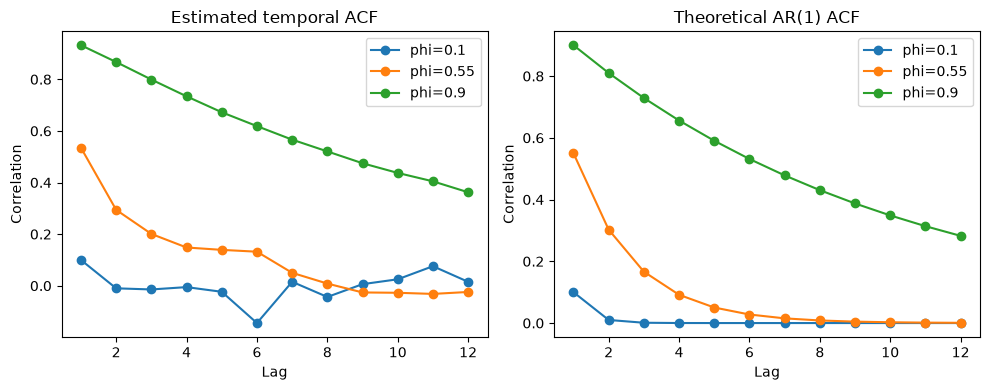

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(19);T=500
fig,axs=plt.subplots(1,2,figsize=(10,4))
for phi in [.1,.55,.9]:
 x=np.zeros(T);noise=rng.normal(size=T)
 for t in range(1,T):x[t]=phi*x[t-1]+noise[t]
 x=x[100:]; ac=[np.corrcoef(x[h:],x[:-h])[0,1] for h in range(1,13)]
 axs[0].plot(range(1,13),ac,marker='o',label=f'phi={phi}')
 axs[1].plot(range(1,13),[phi**h for h in range(1,13)],marker='o',label=f'phi={phi}')
axs[0].set(title='Estimated temporal ACF',xlabel='Lag',ylabel='Correlation')
axs[1].set(title='Theoretical AR(1) ACF',xlabel='Lag',ylabel='Correlation')
for a in axs:a.legend()
plt.tight_layout();plt.show()

```mermaid
flowchart LR
    A[Generate environmental time series] --> B[Align X at t−lag]
    B --> C[Keep common target periods]
    C --> D[Simulate Y at focal t]
    D --> E[Compare lift by lag]
    E --> F[Interpret lag uncertainty]
```

This chapter follows the same structure as the supplied MCLP tutorial: conceptual workflow, formal definition, assumptions, a hand-worked example, executable Python experiments, sensitivity checks, common pitfalls, and a quiz.

---

## Formal Definition and Core Equations

### Notation

| Symbol | Meaning |
|---|---|
| $X_{s,t-\ell}$ | environmental predicate at location $s$ and earlier period |
| $Y_{s,t}$ | target outcome at focal period |
| $\ell$ | specified temporal lag（时间滞后） |
| $\rho$ | persistence parameter in binary process |
| $\beta$ | planted event-effect coefficient |

$$L_\ell=\frac{P(Y_t=1\mid X_{t-\ell}=1)}{P(Y_t=1)}.$$

One illustrative two-state process uses stationary probability $p$ and transitions $P(X_t=1\mid X_{t-1}=x)=\rho x+(1-\rho)p$, where $0\le\rho<1$. Its lag-$h$ correlation is $\rho^h$ in stationarity.

---

## Core Mechanisms and Concepts

### Temporal alignment

The target is observed at $t$ and context at $t-\ell$. Keep the same focal-period population across lags; otherwise the background target prevalence and observation composition change.

### Persistence and lag leakage

If $X_t$ persists, an effect planted at $t-2$ can induce real marginal association at $t-1$ or $t-3$. A detected lag is not automatically the physical or causal delay.

### Seasonal baseline

An event probability that changes by month can be correlated with seasonal environmental conditions even without a direct mechanism. Stratifying randomizations by calendar month is a possible reference restriction, but it is only inferentially valid under the correct within-stratum exchangeability conditions.

### Anchors reused across time

The same spatial support at many focal periods creates clustered observations. A point-process or trajectory-aware reference may preserve aspects of this structure; arbitrary row shuffling generally does not.

## Assumptions, Strengths, Limitations, and Trade-offs

Assume environmental states have a stated transition law and that target outcomes are generated with a prespecified lag in the toy experiment. Strength: known planted temporal structure. Limitation: a stationary first-order Markov process is not a full wildfire climate model.

**Trade-off:** stronger persistence improves continuity of environment but makes adjacent lag associations harder to distinguish.

## Worked Toy Example

If an event probability is increased when $X_{t-2}=1$, a persistent binary climate field produces correlation between $X_{t-2}$ and $X_{t-1}$. Therefore both $L_2$ and $L_1$ may exceed one, although only lag 2 appears in the generating event equation.

## Python Lab: Set Up the Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

SEED = 41020001
rng = np.random.default_rng(SEED)
print("Reproducible random seed:", SEED)

Reproducible random seed: 41020001


## Generate Markov environmental fields

Use many sites and focal periods to visualize temporal persistence.

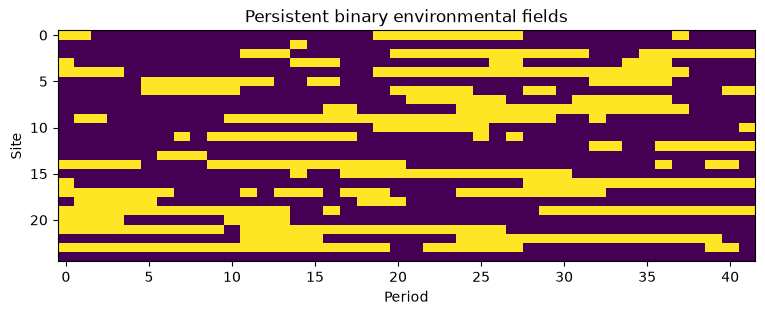

In [3]:
def markov_field(n_sites,T,p=.35,rho=.75,rng=None):
 rng=np.random.default_rng(0) if rng is None else rng
 x=np.zeros((n_sites,T),dtype=int);x[:,0]=rng.binomial(1,p,n_sites)
 for t in range(1,T):
  prob=rho*x[:,t-1]+(1-rho)*p
  x[:,t]=rng.binomial(1,prob)
 return x
X=markov_field(150,42,rho=.75,rng=rng)
fig,ax=plt.subplots(figsize=(9,3));ax.imshow(X[:25],aspect='auto',interpolation='nearest');ax.set(xlabel='Period',ylabel='Site',title='Persistent binary environmental fields');plt.show()

**Interpretation.** At high persistence the binary states form longer temporal runs; adjacent lag predictors are correlated.

## Plant a lag-2 mechanism

Generate Y from lag-2 X without calling the result causal inference.

In [4]:
focal=np.arange(5,42);base_p=.07;beta=1.1
prob=1-np.exp(np.log(1-base_p)*np.exp(beta*X[:,focal-2]))
Y=rng.binomial(1,prob)
print('Target prevalence:',Y.mean(),'focal periods:',len(focal))

Target prevalence: 0.10882882882882883 focal periods: 37


**Interpretation.** The data-generation equation defines a planted delay, but inference from observed rules only characterizes lagged association.

## Plot the lag profile

Use identical target observations for every lag.

   lag     n    K   lift
0    0  1800  277  1.414
1    1  1800  304  1.552
2    2  1796  340  1.740
3    3  1794  308  1.578
4    4  1797  289  1.478
5    5  1802  268  1.367


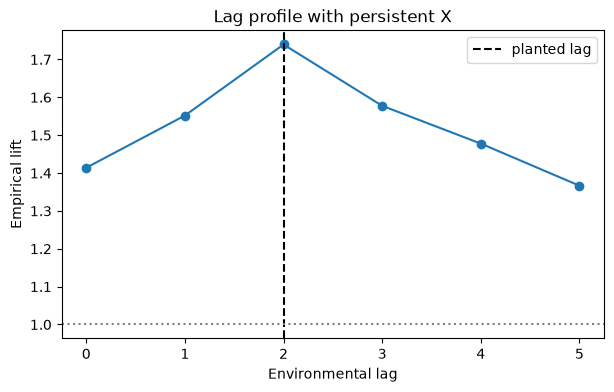

In [5]:
def lag_lifts(X,Y,focal,lags):
 out=[]
 for lag in lags:
  z=X[:,focal-lag].reshape(-1);y=Y.reshape(-1);n=z.sum();m=y.sum();N=len(y);K=np.dot(z,y)
  out.append({'lag':lag,'n':n,'K':K,'lift':K*N/(n*m)})
 return pd.DataFrame(out)
profile=lag_lifts(X,Y,focal,range(6))
print(profile.round(3))
fig,ax=plt.subplots(figsize=(7,4));ax.plot(profile.lag,profile.lift,marker='o');ax.axvline(2,linestyle='--',color='black',label='planted lag');ax.axhline(1,linestyle=':',color='gray');ax.set(xlabel='Environmental lag',ylabel='Empirical lift',title='Lag profile with persistent X');ax.legend();plt.show()

**Interpretation.** A pronounced peak at lag 2 is useful descriptive evidence, but adjacent lags may have genuine noncausal marginal associations.

## Sensitivity to persistence

Repeat independent simulations and average lag-specific lift profiles.

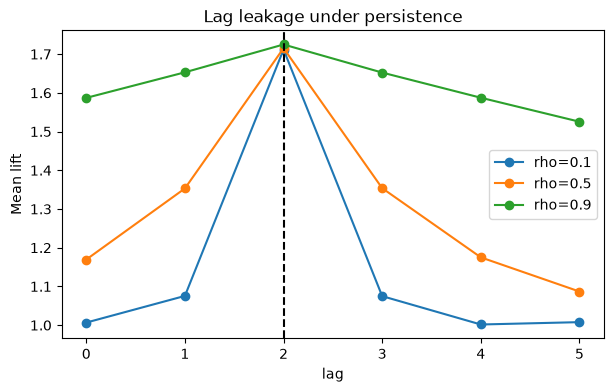

In [6]:
result=[]
for rho in [0.1,0.5,0.9]:
 for rep in range(120):
  xx=markov_field(120,42,rho=rho,rng=rng)
  pp=1-np.exp(np.log(1-base_p)*np.exp(beta*xx[:,focal-2]))
  yy=rng.binomial(1,pp)
  tmp=lag_lifts(xx,yy,focal,range(6));tmp['rho']=rho;tmp['rep']=rep;result.append(tmp)
ans=pd.concat(result).groupby(['rho','lag'],as_index=False).lift.mean()
fig,ax=plt.subplots(figsize=(7,4))
for rho,g in ans.groupby('rho'):ax.plot(g.lag,g.lift,marker='o',label=f'rho={rho}')
ax.axvline(2,linestyle='--',color='black');ax.set(xlabel='lag',ylabel='Mean lift',title='Lag leakage under persistence');ax.legend();plt.show()

**Interpretation.** Lag persistence broadens the lift profile around the planted mechanism; a lagged rule is not a uniquely identified causal delay.

---

## Common Pitfalls and Misunderstandings

- Different eligible anchors across lags make lift comparisons ambiguous.
- Temporal ordering by itself does not establish causality.
- A lagged association can be induced by serial dependence and shared seasonality.
- Repeated location-months are not independent observations by default.
- Annual vegetation observed after a focal event should be called context, not necessarily a precursor.

---

## Quiz — Self-Assessment (Answers Hidden)

Try each question before expanding **Answer**. The folded format follows the supplied `mclp.ipynb` template.

### Q1: What makes an AR(1) model weakly stationary in the usual setup?

A. phi>1  
B. abs(phi)<1 with stable innovation variance  
C. No random noise  
D. A finite series length

<details>
<summary>Answer</summary>

**B. In the usual AR(1) model, |phi|<1 gives finite stationary variance.**

</details>

---

### Q2: Can an association at lag 1 be real when the generating mechanism acts only at lag 2?

A. Never  
B. Yes, through temporal persistence  
C. Only if simulation is wrong  
D. Only with spatial overlap

<details>
<summary>Answer</summary>

**B. Correlated antecedent history can create genuine marginal associations at nearby lags.**

</details>

---

### Q3: Why is seasonal shuffling not automatically valid?

A. It always loses too much data  
B. It requires within-stratum exchangeability  
C. It is only for daily series  
D. It is equivalent to CSR

<details>
<summary>Answer</summary>

**B. Conditioning on month does not by itself justify arbitrary label allocation within that month.**

</details>

---

### Q4: What is the danger of using an annual measurement collected after an event?

A. Increased variance only  
B. Look-ahead leakage and misleading temporal interpretation  
C. It ensures stationarity  
D. None

<details>
<summary>Answer</summary>

**B. Future information cannot be treated as an antecedent exposure.**

</details>

---

### Reflection Question (no prescribed solution)

Name one assumption violation in your own research area and propose a simulation to measure how much it matters.


---

## Suggested Reading and STARM Crosswalk

- Agrawal & Srikant (1994): frequent-itemset search (background).
- Hope (1968); Phipson & Smyth (2010): randomization/Monte Carlo p-values (Chapter B).
- Benjamini & Hochberg (1995); Benjamini & Yekutieli (2001): multiple testing and dependence (Chapter C).
- Baddeley, Rubak & Turner (2015): spatial point patterns (Chapter D).
- Winkler et al. (2014): exchangeability blocks and permutation designs (Chapters B, D, E).
- STARM manuscript: Sections 3.3–3.6 for reference assumptions; Section 4 for simulations; Sections 5–6 for empirical limitations.

**Practice task:** Write a short reviewer note distinguishing a descriptive association from an inferential discovery, explicitly naming the null model and its assumptions.